In [7]:
from cryo_temp_monitor.cryo_temp_data_remote_copy import PiFileTransfer

In [8]:
from cryo_temp_monitor.remote_pi_config import pi_config

RPI = PiFileTransfer(pi_config)

Connection to 100.88.110.107 successful!


In [9]:
RPI.sftp.listdir(RPI.remote_dir)

['20260331_cool_down.csv']

In [10]:
RPI.sync_files()

Saving to: /Users/FGB/Projects/lab_data_logging/cryo_cool_down/2026
-> 20260331_cool_down.csv: Transfer complete.


/var/folders/px/k0r95vj55f3b9_cmpdssstsm0000gn/T/ipykernel_18713/1207444687.py:11: UserWarning: Parsing dates in %d/%m/%Y %H:%M:%S format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['Timestamp'] = pd.to_datetime(df.iloc[:, 0].astype(str) + ' ' + df.iloc[:, 1].astype(str))


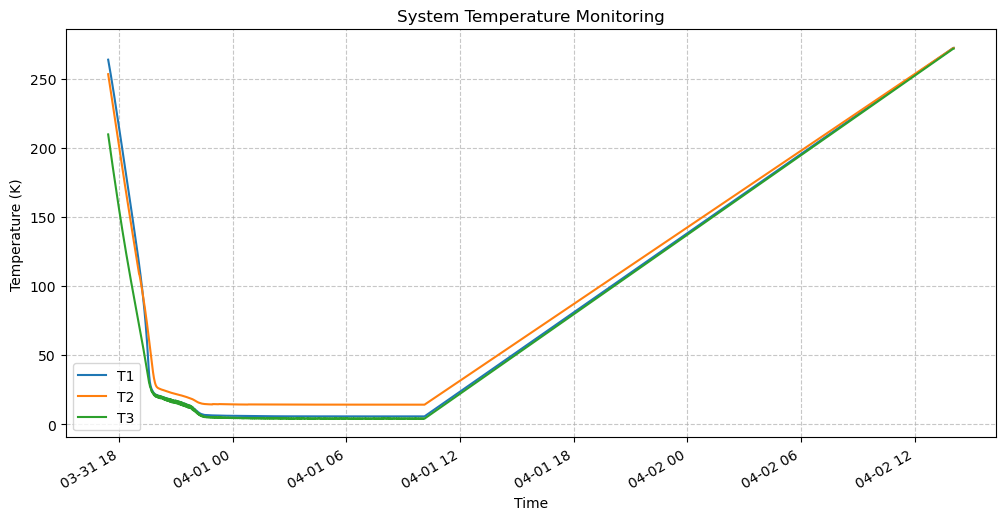

In [12]:
import matplotlib.pyplot as plt
import pandas as pd

data_path = r'/Users/FGB/Projects/lab_data_logging/cryo_cool_down/2026/20260331_cool_down.csv'

# Load your data (example)
df = pd.read_csv(data_path)

# Combine the first two columns into a single 'Timestamp'
# We use .astype(str) to ensure they are treated as text during concatenation
df['Timestamp'] = pd.to_datetime(df.iloc[:, 0].astype(str) + ' ' + df.iloc[:, 1].astype(str))

# Set the Timestamp as the index for easier plotting
df.set_index('Timestamp', inplace=True)

# Create the plot
plt.figure(figsize=(12, 6))

# Plot each column
plt.plot(df.index, df['T1 (K)'], label='T1')
plt.plot(df.index, df['T2 (K)'], label='T2')
plt.plot(df.index, df['T3 (K)'], label='T3')

# Formatting
plt.title('System Temperature Monitoring')
plt.xlabel('Time')
plt.ylabel('Temperature (K)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

# Auto-format the dates on the x-axis to prevent overlapping
plt.gcf().autofmt_xdate()

plt.show()